# Análisis de resultados H4 — precisión nativa × capacidad

Réplica del análisis de `results_analisis.ipynb` sobre la corrida completa de H4
(`../outputs/results/h4_results.csv`): 132 corridas = 5 familias precisión×dispositivo
(fp32-gpu, fp16-gpu, bf16-gpu, fp32-cpu, ternary-cpu) × 7 anchos × 2 profundidades × 2 semillas.

Diferencias de formato respecto al CSV crudo (celda 1):

* `extra` (JSON) se aplana a `eval_every`, `n_episodes_budget`, `simulation_time_scale`, `es_reason`.
* `throughput_by_batch` (JSON por tamaño de lote) se aplana a `throughput_bs{1,8,32,128}_pps` y `ms_per_batch_bs{...}`.
* Se conservan las columnas derivadas del notebook anterior (`n_layers`, `model_size_metric`)
  y se agregan las propias de H4 (`seconds_per_episode`, `compression_ratio`, `packed_bytes_per_param`).


## 1. Data prep — formateo de la información y export a parquet

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

RAW_CSV = Path("../outputs/results/h4_results.csv")
OUT_PARQUET = Path("data/data_h4.parquet")

df = pd.read_csv(RAW_CSV)
print("CSV crudo:", df.shape)

# --- 1. aplanar `extra` (metadatos de la corrida) -------------------------
extra = df["extra"].map(json.loads).apply(pd.Series)
df = df.join(extra[["eval_every", "n_episodes_budget", "simulation_time_scale"]])
df["es_reason"] = extra["es_reason"]
df["notes"] = df["es_reason"]          # mismo nombre que usaba data.parquet

# --- 2. aplanar `throughput_by_batch` (curva throughput vs tamaño de lote) -
tbb = df["throughput_by_batch"].map(json.loads)
batch_sizes = sorted(int(k) for d in tbb for k in d)
for bs in batch_sizes:
    df[f"throughput_bs{bs}_pps"] = tbb.map(lambda d, bs=bs: d.get(str(bs), {}).get("samples_per_sec"))
    df[f"ms_per_batch_bs{bs}"] = tbb.map(lambda d, bs=bs: d.get(str(bs), {}).get("ms_per_batch"))
df["throughput_scaling_x"] = df[f"throughput_bs{max(batch_sizes)}_pps"] / df[f"throughput_bs{min(batch_sizes)}_pps"]

# --- 3. etiquetas legibles -------------------------------------------------
LABELS = {"32": "fp32", "16": "fp16", "bf16": "bf16", "ternary": "ternary"}
df["precision_label"] = df["precision"].astype(str).str.strip().map(LABELS)
df["device_precision"] = df["device"] + "-" + df["precision_label"]
df["n_layers"] = df["n_hidden_layers"]     # paridad con data.parquet / notebook anterior

# --- 4. métricas derivadas -------------------------------------------------
df["model_size_metric"] = df["n_layers"] * df["hidden_size"] * df["bits"]   # definición del notebook anterior
df["log_model_size"] = np.log(df["model_size_metric"])
df["compression_ratio"] = 32.0 / df["bits"]              # vs pesos fp32 nativos
df["packed_bytes_per_param"] = df["packed_size_mb"] * 2**20 / df["params"]
df["seconds_per_episode"] = df["wall_clock_s"] / df["episodes_trained"]   # menos confundido por el early stopping

df = (
    df.drop(columns=["extra", "throughput_by_batch"])
      .sort_values(["device", "precision_label", "hidden_size", "n_layers", "seed"])
      .reset_index(drop=True)
)

OUT_PARQUET.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUT_PARQUET, index=False)

print(f"formateado: {df.shape[0]} filas x {df.shape[1]} columnas -> {OUT_PARQUET}")
print("\ncolumnas:", list(df.columns))

print("\nResumen por familia precisión×dispositivo:")
resumen = df.groupby("device_precision").agg(
    corridas=("experiment_id", "size"),
    semillas=("seed", "nunique"),
    anchos=("hidden_size", "nunique"),
    ancho_min=("hidden_size", "min"),
    ancho_max=("hidden_size", "max"),
    profundidades=("n_layers", lambda s: sorted(s.unique())),
    param_min=("params", "min"),
    param_max=("params", "max"),
    packed_mb_min=("packed_size_mb", "min"),
    packed_mb_max=("packed_size_mb", "max"),
)
print(resumen.to_string())

print("\nCortes tempranos (early stopping):", df["stopped_early"].value_counts().to_dict())
print("episodes_trained:", df["episodes_trained"].value_counts().sort_index().to_dict())
print("constantes (sin información):", [c for c in df.columns if df[c].nunique(dropna=False) == 1])

CSV crudo: (132, 33)
formateado: 132 filas x 53 columnas -> data/data_h4.parquet

columnas: ['experiment_id', 'precision', 'bits', 'hidden_size', 'n_hidden_layers', 'episodes_trained', 'stopped_early', 'best_episode', 'best_mean_reward', 'best_eval_reward', 'best_eval_episode', 'latency_mean_ms', 'latency_p50_ms', 'latency_p95_ms', 'latency_n_samples', 'throughput_pps', 'throughput_batch_size', 'params', 'packed_size_mb', 'flops', 'effective_capacity_bits', 'avg_steps', 'norm_reward', 'eval_episodes', 'eval_mean_reward', 'eval_makespan', 'eval_sla_violations', 'eval_sla_rate', 'wall_clock_s', 'device', 'seed', 'eval_every', 'n_episodes_budget', 'simulation_time_scale', 'es_reason', 'notes', 'throughput_bs1_pps', 'ms_per_batch_bs1', 'throughput_bs8_pps', 'ms_per_batch_bs8', 'throughput_bs32_pps', 'ms_per_batch_bs32', 'throughput_bs128_pps', 'ms_per_batch_bs128', 'throughput_scaling_x', 'precision_label', 'device_precision', 'n_layers', 'model_size_metric', 'log_model_size', 'compression

In [2]:
df = pd.read_parquet("data/data_h4.parquet")
print(df.shape)
print(df.dtypes.to_string())
df.head(5)

(132, 53)
experiment_id                  str
precision                      str
bits                       float64
hidden_size                  int64
n_hidden_layers              int64
episodes_trained             int64
stopped_early                 bool
best_episode                 int64
best_mean_reward           float64
best_eval_reward           float64
best_eval_episode            int64
latency_mean_ms            float64
latency_p50_ms             float64
latency_p95_ms             float64
latency_n_samples            int64
throughput_pps             float64
throughput_batch_size        int64
params                       int64
packed_size_mb             float64
flops                      float64
effective_capacity_bits    float64
avg_steps                  float64
norm_reward                float64
eval_episodes                int64
eval_mean_reward           float64
eval_makespan              float64
eval_sla_violations        float64
eval_sla_rate              float64
wall_clock

,experiment_id,precision,bits,hidden_size,n_hidden_layers,episodes_trained,stopped_early,best_episode,best_mean_reward,best_eval_reward,...,ms_per_batch_bs128,throughput_scaling_x,precision_label,device_precision,n_layers,model_size_metric,log_model_size,compression_ratio,packed_bytes_per_param,seconds_per_episode
0,h4_native_precision_32_cpu_h64_l1_s41,32,32.0,64,1,400,False,400,-4513.506539,-4482.615569,...,0.024151,69.573247,fp32,cpu-fp32,1,2048.0,7.624619,1.0,4.194304,0.474841
1,h4_native_precision_32_cpu_h64_l1_s42,32,32.0,64,1,200,True,50,-4625.205679,-4625.205679,...,0.022122,73.503629,fp32,cpu-fp32,1,2048.0,7.624619,1.0,4.194304,0.415832
2,h4_native_precision_32_cpu_h64_l2_s41,32,32.0,64,2,200,True,50,-4608.642721,-4608.642721,...,0.052796,44.440750,fp32,cpu-fp32,2,4096.0,8.317766,1.0,4.194304,0.439323
3,h4_native_precision_32_cpu_h64_l2_s42,32,32.0,64,2,200,True,50,-4598.817356,-4598.817356,...,0.048906,48.574632,fp32,cpu-fp32,2,4096.0,8.317766,1.0,4.194304,0.440395
4,h4_native_precision_32_cpu_h128_l1_s41,32,32.0,128,1,200,True,50,-4608.439355,-4608.439355,...,0.024418,63.443701,fp32,cpu-fp32,1,4096.0,8.317766,1.0,4.194304,0.417604


## 2. Desempeño vs tamaño

Misma métrica de tamaño que el notebook anterior: `model_size_metric = n_layers × hidden_size × bits`
(no se usa `params` porque `bits` ya captura el costo por peso). La escala del eje X es logarítmica.

Dos cambios respecto al notebook anterior, forzados por los datos de H4:

* el color es `precision_label` en vez de `bits`, porque ternary tiene `bits = 1.58` (no es una
  escala discreta limpia) y porque fp16/bf16 comparten 16 bits;
* se excluyen `eval_sla_rate` y `eval_sla_violations`: son **constantes** (0 en las 132 corridas,
  ninguna configuración viola el SLA), así que no tienen correlación definida.


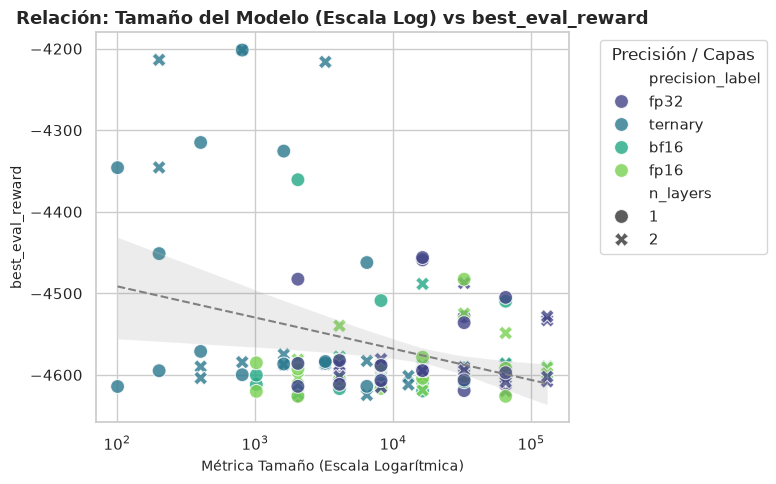

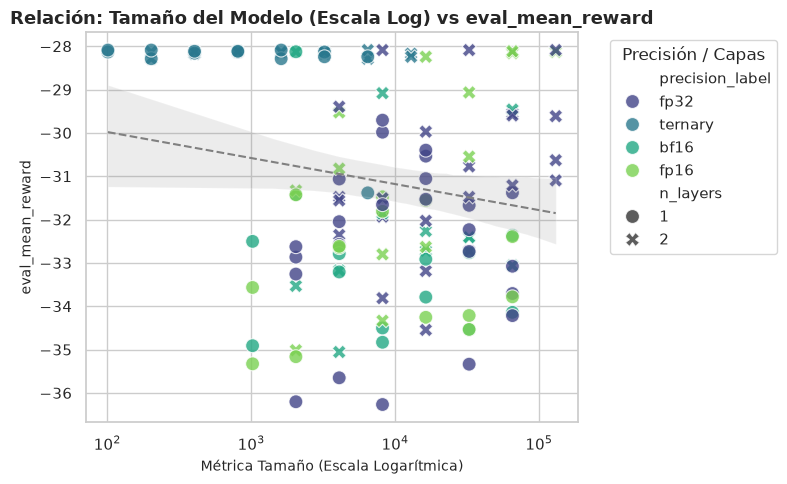

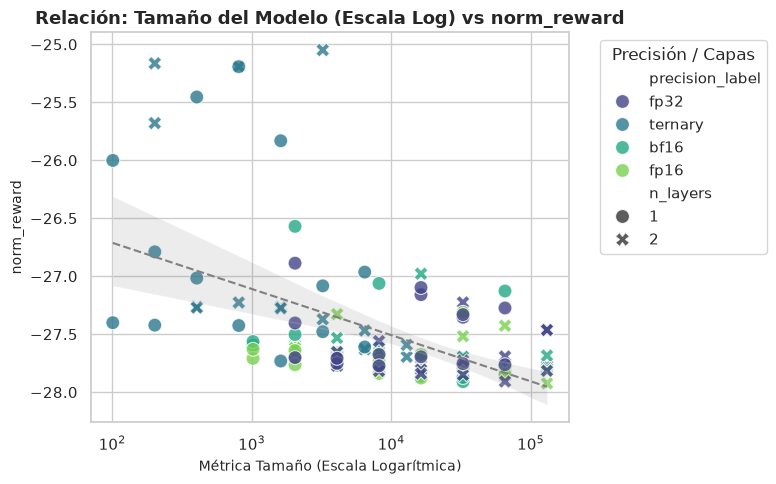

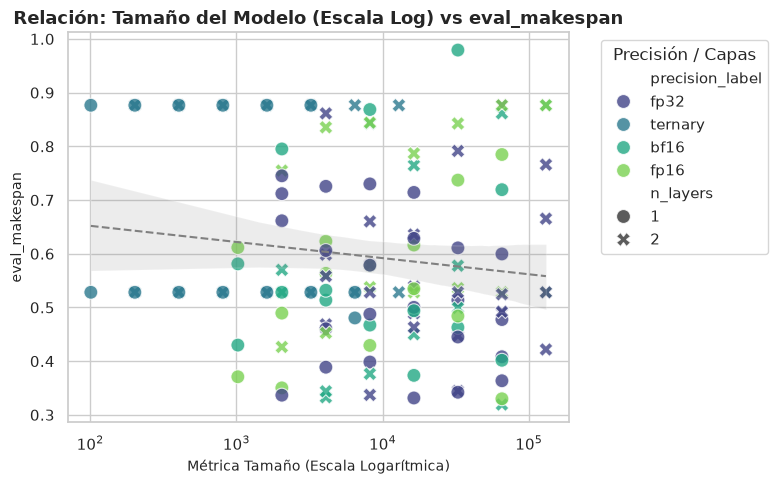

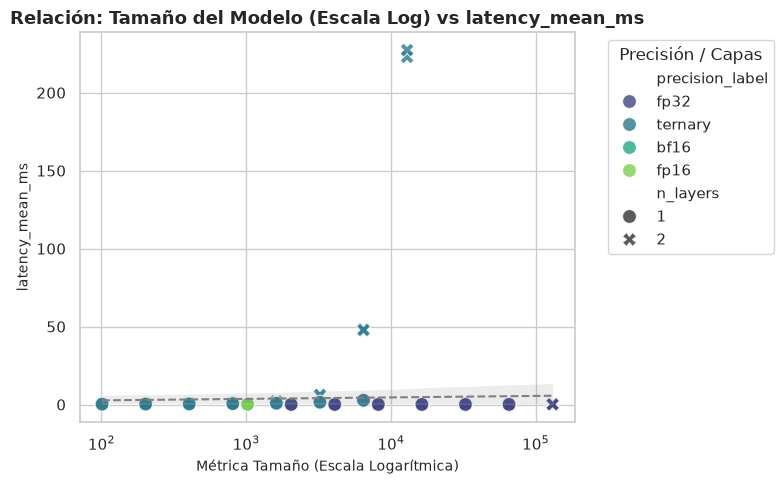

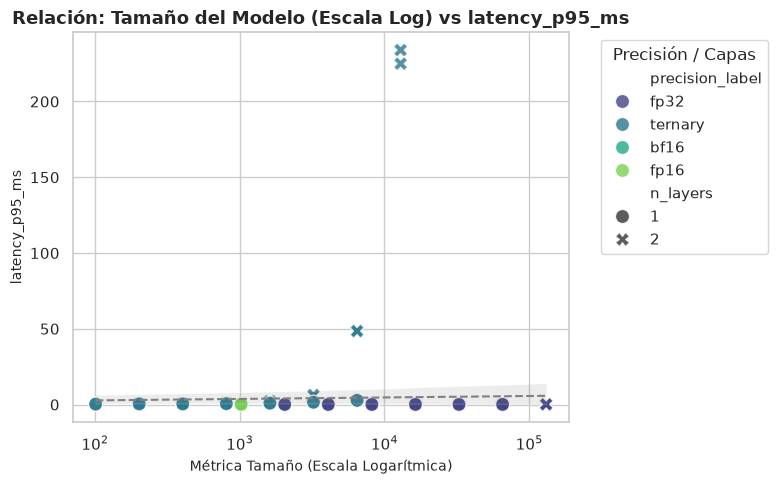

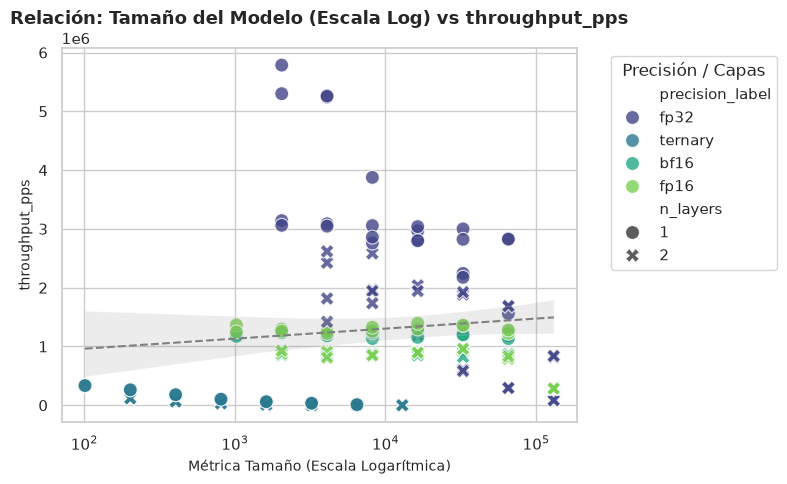

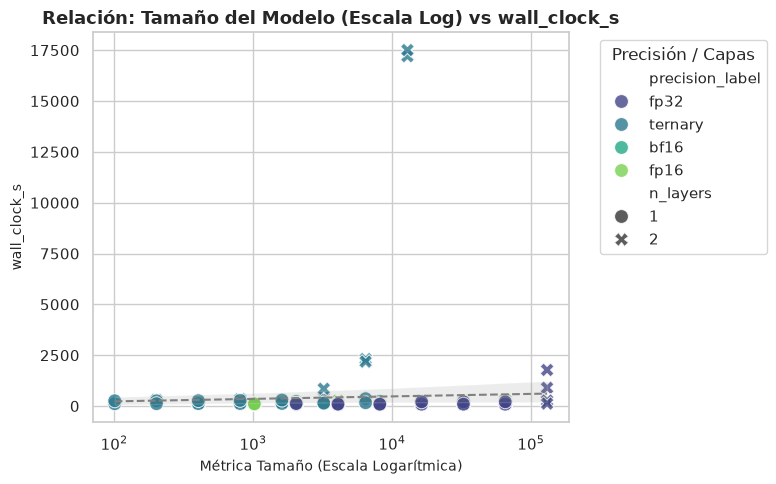

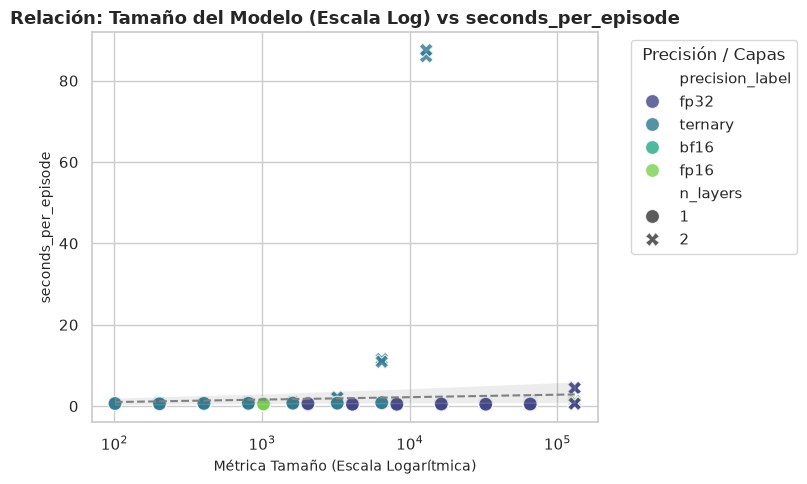

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

QUALITY_METRICS = ["best_eval_reward", "eval_mean_reward", "norm_reward", "eval_makespan"]
COST_METRICS = ["latency_mean_ms", "latency_p95_ms", "throughput_pps", "wall_clock_s", "seconds_per_episode"]
performance_metrics = QUALITY_METRICS + COST_METRICS

sns.set_theme(style="whitegrid")

for metric in performance_metrics:
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x="model_size_metric",
        y=metric,
        hue="precision_label",
        style="n_layers",
        palette="viridis",
        s=100,
        alpha=0.8,
    )

    sns.regplot(
        data=df,
        x="model_size_metric",
        y=metric,
        scatter=False,
        logx=True,
        color="gray",
        line_kws={"linestyle": "--", "linewidth": 1.5},
    )

    plt.xscale("log")
    plt.title(f"Relación: Tamaño del Modelo (Escala Log) vs {metric}", fontsize=13, fontweight="bold")
    plt.xlabel("Métrica Tamaño (Escala Logarítmica)", fontsize=10)
    plt.ylabel(metric, fontsize=10)
    plt.legend(title="Precisión / Capas", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### 2.1 Regresión log-lineal: `métrica ~ log(model_size_metric)`

Igual que el notebook anterior (OLS + Pearson), agregando `n` y separando calidad vs costo.

In [4]:
from scipy.stats import pearsonr
import statsmodels.api as sm

results = []

for metric in performance_metrics:
    clean_df = df[["log_model_size", metric]].dropna()

    X_log = clean_df["log_model_size"]
    y = clean_df[metric]

    model = sm.OLS(y, sm.add_constant(X_log)).fit()
    r_pearson, _ = pearsonr(X_log, y)

    results.append(
        {
            "Grupo": "calidad" if metric in QUALITY_METRICS else "costo",
            "Métrica (y)": metric,
            "n": len(clean_df),
            "Pearson (r)": r_pearson,
            "Pendiente (β1)": model.params["log_model_size"],
            "Intersección (β0)": model.params["const"],
            "R²": model.rsquared,
            "R² Ajustado": model.rsquared_adj,
            "p-value (β1 OLS)": model.pvalues["log_model_size"],
            "Error Estándar": model.bse["log_model_size"],
        }
    )

df_regression = pd.DataFrame(results).round(5)
print(df_regression.to_string(index=False))

  Grupo         Métrica (y)   n  Pearson (r)  Pendiente (β1)  Intersección (β0)      R²  R² Ajustado  p-value (β1 OLS)  Error Estándar
calidad    best_eval_reward 132     -0.32587       -16.62149        -4414.77721 0.10619      0.09931           0.00014         4.22942
calidad    eval_mean_reward 132     -0.18308        -0.26078          -28.77891 0.03352      0.02608           0.03562         0.12281
calidad         norm_reward 132     -0.50941        -0.17303          -25.91427 0.25949      0.25380           0.00000         0.02564
calidad       eval_makespan 132     -0.12935        -0.01306            0.71213 0.01673      0.00917           0.13935         0.00878
  costo     latency_mean_ms 132      0.02515         0.41339            0.76991 0.00063     -0.00706           0.77472         1.44138
  costo      latency_p95_ms 132      0.02501         0.41893            0.81302 0.00063     -0.00706           0.77592         1.46875
  costo      throughput_pps 132      0.10798     74234.

**Lectura.** Se reproduce el resultado del notebook anterior: mezclando CPU y CUDA, ninguna
métrica de costo se relaciona con el tamaño (|r| < 0.11 y p > 0.2 en latencia, throughput,
wall clock y seconds_per_episode). En calidad aparecen relaciones débiles y **negativas**
(`norm_reward` r = -0.51, p < 1e-3; `best_eval_reward` r = -0.33). Ojo con leer eso como "más
grande = peor": la pendiente la carga una sola familia, porque los 8 mejores `best_eval_reward` del
barrido son todos de `cpu-ternary`. Fuera de ternary el signo se desvanece o se invierte
(`best_eval_reward` r = +0.08, p = 0.42; `eval_mean_reward` r = +0.34, p = 4e-4), y la razón de
fondo está en la sección 5.5: la evaluación de `cpu-ternary` depende de la semilla y no del modelo.
Abajo se separa además por dispositivo.

## 3. Separando CPU y CUDA

Como en el notebook anterior: a esta escala de modelos el overhead (sobre todo el de GPU)
tapa la tendencia, así que la regresión se repite por dispositivo.

In [5]:
target_metrics = [
    "latency_mean_ms",
    "latency_p95_ms",
    "throughput_pps",
    "wall_clock_s",
    "seconds_per_episode",
    "eval_mean_reward",
]

results = []

for device in sorted(df["device"].unique()):
    df_device = df[df["device"] == device]

    for metric in target_metrics:
        clean_df = df_device[["log_model_size", metric]].dropna()

        if len(clean_df) < 3:      # sin puntos suficientes no hay regresión válida
            continue

        X_log = clean_df["log_model_size"]
        y = clean_df[metric]

        model = sm.OLS(y, sm.add_constant(X_log)).fit()
        r_pearson, _ = pearsonr(X_log, y)

        results.append(
            {
                "Device": device,
                "Métrica (y)": metric,
                "n": len(clean_df),
                "Pearson (r)": r_pearson,
                "Pendiente (β1)": model.params["log_model_size"],
                "Intersección (β0)": model.params["const"],
                "R²": model.rsquared,
                "R² Ajustado": model.rsquared_adj,
                "p-value (β1 OLS)": model.pvalues["log_model_size"],
                "Error Estándar": model.bse["log_model_size"],
            }
        )

df_device_regression = pd.DataFrame(results).round(5).sort_values(by=["Métrica (y)", "Device"])
print(df_device_regression.to_string(index=False))

Device         Métrica (y)  n  Pearson (r)  Pendiente (β1)  Intersección (β0)      R²  R² Ajustado  p-value (β1 OLS)  Error Estándar
   cpu    eval_mean_reward 52     -0.46821        -0.57882      -2.518370e+01 0.21922      0.20361           0.00046         0.15448
  cuda    eval_mean_reward 80      0.32705         0.51528      -3.674861e+01 0.10696      0.09551           0.00307         0.16858
   cpu     latency_mean_ms 52      0.13256         3.07407      -1.424907e+01 0.01757     -0.00208           0.34884         3.25052
  cuda     latency_mean_ms 80      0.35323         0.01903      -4.048000e-02 0.12477      0.11355           0.00131         0.00571
   cpu      latency_p95_ms 52      0.13227         3.12563      -1.446146e+01 0.01750     -0.00215           0.34992         3.31249
  cuda      latency_p95_ms 80      0.34903         0.01947      -3.043000e-02 0.12182      0.11057           0.00151         0.00592
   cpu seconds_per_episode 52      0.14832         1.30337      -6.23

**Lectura.** Al separar por dispositivo sí aparece estructura, y es asimétrica:

* **CUDA** (80 corridas): el costo crece con el tamaño — `seconds_per_episode` r = 0.45 (p = 3e-5),
  `wall_clock_s` r = 0.39 (p = 3e-4), `latency_mean_ms` r = 0.35 (p = 0.001) — y el reward también
  mejora con el tamaño (r = +0.33, p = 0.003).
* **CPU** (52 corridas): nada significativo (el menor p es 0.19, en throughput). El tiempo por paso en CPU lo domina el
  overhead fijo, no el ancho del modelo; y el reward **empeora** al crecer (r = -0.47, p = 5e-4).

O sea: en GPU el tamaño se traduce en tiempo y en mejor política; en CPU el tamaño solo encarece el
entrenamiento sin mejorar el resultado. Por eso la mezcla global "no veía" la tendencia.

## 4. Foco en el costo de entrenamiento

`wall_clock_s` era la métrica elegida en el notebook anterior. En H4 el sospechoso natural es el
early stopping: corta cada corrida a las 200, 250 o 400 épocas, así que `wall_clock_s` podría estar
midiendo cuánto duró la corrida y no cuánto cuesta el modelo. Se comprueba, y de paso se define
`seconds_per_episode = wall_clock_s / episodes_trained` como control del presupuesto consumido.

In [6]:
r_wc, p_wc = pearsonr(df["wall_clock_s"], df["episodes_trained"])
r_sp, p_sp = pearsonr(df["seconds_per_episode"], df["episodes_trained"])
print(f"wall_clock_s          vs episodes_trained: r = {r_wc:+.3f}  (p = {p_wc:.2e})")
print(f"seconds_per_episode   vs episodes_trained: r = {r_sp:+.3f}  (p = {p_sp:.2e})")

print("\nwall_clock_s por número de épocas entrenadas:")
print(df.groupby("episodes_trained")["wall_clock_s"].agg(["count", "mean", "min", "max"]).round(1).to_string())

wall_clock_s          vs episodes_trained: r = -0.033  (p = 7.11e-01)
seconds_per_episode   vs episodes_trained: r = -0.064  (p = 4.64e-01)

wall_clock_s por número de épocas entrenadas:
                  count   mean    min      max
episodes_trained                              
200                 103  503.2   83.2  17506.4
250                   2  121.8  107.9    135.7
400                  27  333.3  189.9   1773.7


**Veredicto: el confound no aparece.** `wall_clock_s` no se explica por el número de épocas
(r = -0.03, p = 0.71), así que el ordenamiento por tiempo de entrenamiento es válido: entre las
corridas de 200 épocas el wall clock va de 83 s a 17.506 s (210x) solo por el costo del modelo en su
dispositivo. Se conserva igualmente `seconds_per_episode`, que es la métrica usada en la regresión
por dispositivo y es más sensible al tamaño en CUDA (r = 0.45 frente a 0.39 de `wall_clock_s`).

In [7]:
# Regresión de seconds_per_episode (costo comparable) contra tamaño, por dispositivo
results = []

for device in sorted(df["device"].unique()):
    clean_df = df.loc[df["device"] == device, ["log_model_size", "seconds_per_episode"]].dropna()
    X_log, y = clean_df["log_model_size"], clean_df["seconds_per_episode"]

    model = sm.OLS(y, sm.add_constant(X_log)).fit()
    r_pearson, _ = pearsonr(X_log, y)

    results.append(
        {
            "Device": device,
            "n": len(clean_df),
            "Pearson (r)": r_pearson,
            "Pendiente (β1)": model.params["log_model_size"],
            "Intersección (β0)": model.params["const"],
            "R²": model.rsquared,
            "p-value (β1 OLS)": model.pvalues["log_model_size"],
        }
    )

print(pd.DataFrame(results).round(5).to_string(index=False))

Device  n  Pearson (r)  Pendiente (β1)  Intersección (β0)     R²  p-value (β1 OLS)
   cpu 52      0.14832         1.30337           -6.23209 0.0220           0.29400
  cuda 80      0.44587         0.05104            0.09371 0.1988           0.00003


atípicos descartados: 8 de 132


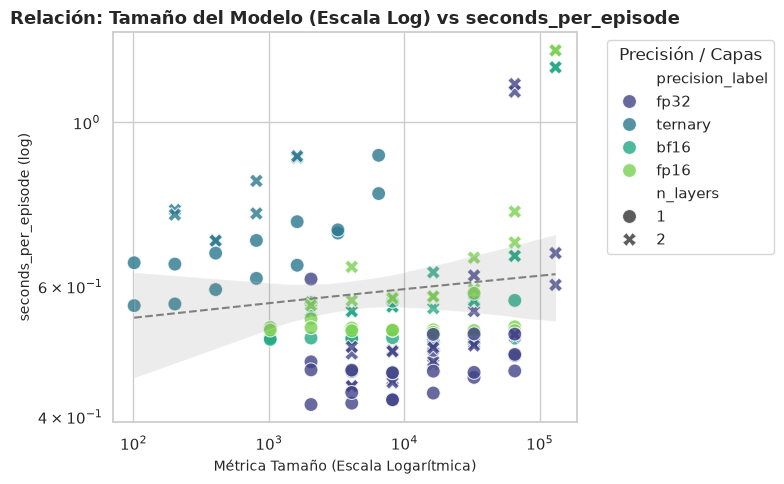

In [8]:
# Gráfica de seconds_per_episode sin atípicos extremos (IQR, igual criterio que el notebook anterior)
q1, q3 = df["seconds_per_episode"].quantile([0.1, 0.9])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
df_filtered = df[df["seconds_per_episode"] <= upper_bound]
print(f"atípicos descartados: {len(df) - len(df_filtered)} de {len(df)}")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_filtered,
    x="model_size_metric",
    y="seconds_per_episode",
    hue="precision_label",
    style="n_layers",
    palette="viridis",
    s=100,
    alpha=0.8,
)

sns.regplot(
    data=df_filtered,
    x="model_size_metric",
    y="seconds_per_episode",
    scatter=False,
    logx=True,
    color="gray",
    line_kws={"linestyle": "--", "linewidth": 1.5},
)

plt.xscale("log")
plt.title("Relación: Tamaño del Modelo (Escala Log) vs seconds_per_episode", fontsize=13, fontweight="bold")
plt.xlabel("Métrica Tamaño (Escala Logarítmica)", fontsize=10)
plt.ylabel("seconds_per_episode (log)", fontsize=10)
plt.yscale("log")
plt.legend(title="Precisión / Capas", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [9]:
# Resumen por familia (device × precision), igual que el notebook anterior
available_metrics = [m for m in performance_metrics if m in df.columns]

df_summary = df.groupby(["device", "precision"], as_index=False)[available_metrics + ["params", "packed_size_mb"]].mean()

df_melted = df_summary.melt(
    id_vars=["device", "precision"],
    var_name="Métrica",
    value_name="Promedio",
)
df_melted["device_precision"] = (
    df_melted["device"].astype(str) + " (Precision " + df_melted["precision"].astype(str) + ")"
)

df_pivot = (
    df_melted.pivot(index="Métrica", columns="device_precision", values="Promedio")
    .reset_index()
    .round(4)
)
print(df_pivot.to_string(index=False))

            Métrica  cpu (Precision 32)  cpu (Precision ternary)  cuda (Precision 16)  cuda (Precision 32)  cuda (Precision bf16)
   best_eval_reward          -4579.4063               -4492.0189           -4588.6963           -4582.8519             -4583.0737
      eval_makespan              0.5417                   0.6882               0.6020               0.5566                 0.5720
   eval_mean_reward            -31.9426                 -28.2812             -31.8445             -31.5008               -32.2213
    latency_mean_ms              0.0460                  20.7160               0.1604               0.0845                 0.1659
     latency_p95_ms              0.0493                  21.1107               0.1795               0.0938                 0.1795
        norm_reward            -27.6320                 -26.8053             -27.7060             -27.6601               -27.5981
     packed_size_mb              1.9107                   0.3196               3.2361     

## 5. Análisis adicional (específico de H4)

Lo anterior es el espejo del notebook 1. Estas son las preguntas que H4 agrega y que el
análisis anterior no cubría: ruido entre semillas, la curva throughput vs tamaño de lote
y la ventaja real de empaquetado de la precisión baja.

In [10]:
# 5.1 ¿Cuánto ruido hay entre las dos semillas? (H4 replica cada celda, P2)
CONFIG = ["device_precision", "hidden_size", "n_layers"]
seed_metrics = ["eval_mean_reward", "best_eval_reward", "norm_reward", "latency_mean_ms", "throughput_bs128_pps"]

rows = []
for metric in seed_metrics:
    g = df.groupby(CONFIG)[metric]
    spread = g.max() - g.min()
    mean_abs = g.mean().abs().replace(0, np.nan)
    rows.append(
        {
            "Métrica": metric,
            "spread_medio": spread.mean(),
            "spread_max": spread.max(),
            "spread_relativo_medio_%": (100 * (spread / mean_abs)).mean(),
        }
    )

df_seed_noise = pd.DataFrame(rows).round(4)
print(df_seed_noise.to_string(index=False))
print("\nConfiguraciones con 2 semillas:", df.groupby(CONFIG).size().eq(2).sum(), "de", df.groupby(CONFIG).ngroups)

             Métrica  spread_medio  spread_max  spread_relativo_medio_%
    eval_mean_reward        1.5769      6.2829                   4.9584
    best_eval_reward       71.5083    398.1000                   1.5922
         norm_reward        0.3912      2.3224                   1.4525
     latency_mean_ms        0.0839      4.4286                   4.6878
throughput_bs128_pps    85615.8590 820434.5836                   5.1706

Configuraciones con 2 semillas: 66 de 66


In [11]:
# 5.2 Calidad comparable: ¿una red más ancha en baja precisión iguala a fp32?
#    Comparación controlada por arquitectura (mismo hidden_size y n_layers), media sobre semillas.
quality_ctrl = (
    df.pivot_table(
        index=["hidden_size", "n_layers"],
        columns="device_precision",
        values="eval_mean_reward",
        aggfunc="mean",
    )
    .round(3)
)
print("eval_mean_reward (media sobre semillas) — mismo ancho/profundidad por fila:")
print(quality_ctrl.to_string())

speed_ctrl = (
    df.pivot_table(
        index=["hidden_size", "n_layers"],
        columns="device_precision",
        values="latency_mean_ms",
        aggfunc="mean",
    )
    .round(5)
)
print("\nlatency_mean_ms (forward pass) — mismo ancho/profundidad por fila:")
print(speed_ctrl.to_string())

eval_mean_reward (media sobre semillas) — mismo ancho/profundidad por fila:
device_precision      cpu-fp32  cpu-ternary  cuda-bf16  cuda-fp16  cuda-fp32
hidden_size n_layers                                                        
64          1          -34.535      -28.112    -33.707    -34.448    -32.941
            2          -31.917      -28.209    -30.830    -33.172    -30.478
128         1          -31.819      -28.190    -29.775    -33.297    -33.850
            2          -32.873      -28.145    -34.115    -30.177    -29.799
256         1          -33.126      -28.140    -32.997    -32.633    -30.681
            2          -31.579      -28.126    -30.471    -33.568    -33.288
512         1          -30.468      -28.126    -34.666    -31.643    -31.293
            2          -31.750      -28.145    -32.492    -30.438    -29.784
1024        1          -33.504      -28.190    -33.352    -32.907    -32.484
            2          -28.841      -28.151    -32.401    -29.808    -30.404


**Lectura — calidad.** A igual ancho y profundidad, `cpu-ternary` obtiene el mejor
`eval_mean_reward` y es casi invariante al ancho (-28.1 en h=64 ... -29.8 en h=4096), mientras
fp32/bf16/fp16 oscilan entre -28.1 y -34.7. Dos advertencias antes de leer eso como superioridad de
la precisión baja:

1. esa invariancia al ancho **no es calidad**: en `cpu-ternary` el `eval_mean_reward` toma 9 valores
   distintos en 28 corridas y se repite idéntico en anchos muy diferentes (h=64 y h=2048 con la misma
   semilla dan el mismo número). La evaluación de esa familia la determina la semilla, no el modelo
   (sección 5.5), así que sus comparaciones no son concluyentes; además el spread entre semillas de
   `eval_mean_reward` llega a 6.3 unidades (sección 5.1), del mismo orden que las diferencias entre
   familias: con 2 semillas no se separa efecto de ruido;
2. el ranking **cambia con la métrica**: `cpu-ternary` tiene el mejor reward pero el peor makespan
   (0.688 vs 0.541 de `cpu-fp32`, tabla anterior). El reward energy-only no ordena igual que la
   métrica de negocio, y eso hay que resolverlo antes de concluir algo sobre precisión.

**Lectura — velocidad.** `cuda-fp32` es el forward más rápido (0.065-0.118 ms) y fp16/bf16 con AMP
son **más lentos** (0.12-0.43 ms): a esta escala el cast de autocast cuesta más de lo que ahorra.
`cpu-ternary` es 15x más lento que `cpu-fp32` en h=64 y hasta 204x en h=2048 con 2 capas.

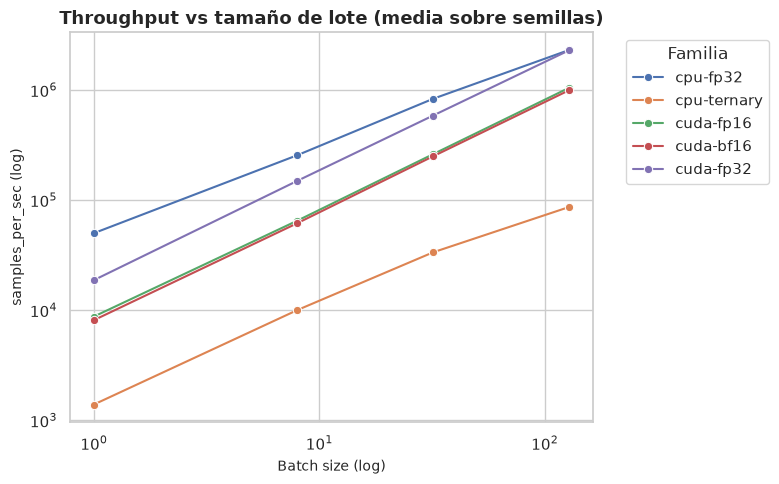


Samples/s por lote:
device_precision   cpu-fp32  cpu-ternary  cuda-bf16  cuda-fp16  cuda-fp32
batch_size                                                               
1                   50137.0       1394.0     8134.0     8765.0    18780.0
8                  256299.0      10056.0    61875.0    65211.0   149935.0
32                 833155.0      33619.0   250460.0   261780.0   587105.0
128               2307525.0      86519.0   993838.0  1045656.0  2291703.0

Escalamiento bs1->bs128 (x veces):
device_precision
cpu-fp32        46.0
cpu-ternary     62.1
cuda-bf16      122.2
cuda-fp16      119.3
cuda-fp32      122.0


In [12]:
# 5.3 Curva throughput vs tamaño de lote (la razón de existir de throughput_by_batch)
bs_cols = [c for c in df.columns if c.startswith("throughput_bs") and c.endswith("_pps")]

long = df.melt(
    id_vars=["device_precision", "seed"],
    value_vars=bs_cols,
    var_name="batch_size",
    value_name="samples_per_sec",
)
long["batch_size"] = long["batch_size"].str.extract(r"bs(\d+)_").astype(int)

curve = (
    long.groupby(["device_precision", "batch_size"], as_index=False)["samples_per_sec"]
    .mean()
    .sort_values("batch_size")
)

plt.figure(figsize=(8, 5))
sns.lineplot(data=curve, x="batch_size", y="samples_per_sec", hue="device_precision", marker="o")
plt.xscale("log")
plt.yscale("log")
plt.title("Throughput vs tamaño de lote (media sobre semillas)", fontsize=13, fontweight="bold")
plt.xlabel("Batch size (log)", fontsize=10)
plt.ylabel("samples_per_sec (log)", fontsize=10)
plt.legend(title="Familia", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

wide = curve.pivot(index="batch_size", columns="device_precision", values="samples_per_sec")
print("\nSamples/s por lote:")
print(wide.round(0).to_string())
print("\nEscalamiento bs{0}->bs{1} (x veces):".format(wide.index.min(), wide.index.max()))
print((wide.loc[wide.index.max()] / wide.loc[wide.index.min()]).round(1).to_string())

In [13]:
# 5.4 Ventaja de la precisión baja: memoria empaquetada vs throughput real
#    (mismo ancho y profundidad, media sobre semillas)
adv = (
    df.groupby(["device_precision", "hidden_size", "n_layers"], as_index=False)
    .agg(
        params=("params", "mean"),
        packed_size_mb=("packed_size_mb", "mean"),
        bytes_por_param=("packed_bytes_per_param", "mean"),
        latency_mean_ms=("latency_mean_ms", "mean"),
        throughput_bs128_pps=("throughput_bs128_pps", "mean"),
        throughput_scaling_x=("throughput_scaling_x", "mean"),
        eval_mean_reward=("eval_mean_reward", "mean"),
    )
)

print("Comparación a ancho fijo h=512, 2 capas:")
print(adv.query("hidden_size == 512 and n_layers == 2").drop(columns=["hidden_size", "n_layers"]).round(4).to_string(index=False))

print("\nCompresión teórica vs fp32 y tamaño empaquetado real (h=512, 2 capas):")
print(
    df.query("hidden_size == 512 and n_layers == 2")
    .groupby("device_precision")[["bits", "compression_ratio", "packed_size_mb"]]
    .mean()
    .round(4)
    .to_string()
)

Comparación a ancho fijo h=512, 2 capas:
device_precision   params  packed_size_mb  bytes_por_param  latency_mean_ms  throughput_bs128_pps  throughput_scaling_x  eval_mean_reward
        cpu-fp32 271364.0          1.0855           4.1943           0.0466           597182.1611               24.3973          -31.7497
     cpu-ternary 271364.0          0.0536           0.2071           2.0697            10570.6234               21.4421          -28.1453
       cuda-bf16 271364.0          0.5427           2.0972           0.1585           879547.6363              120.7344          -32.4919
       cuda-fp16 271364.0          0.5427           2.0972           0.1600           899813.9981              114.3294          -30.4384
       cuda-fp32 271364.0          1.0855           4.1943           0.0981          1903939.5898              131.1253          -29.7841

Compresión teórica vs fp32 y tamaño empaquetado real (h=512, 2 capas):
                   bits  compression_ratio  packed_size_mb


In [14]:
# 5.5 Señal de alerta: la familia cpu-ternary colapsa a la misma evaluación
por_familia = df.groupby("device_precision").agg(
    corridas=("experiment_id", "size"),
    unicos_eval_mean_reward=("eval_mean_reward", lambda s: s.round(6).nunique()),
    unicos_eval_makespan=("eval_makespan", lambda s: s.round(6).nunique()),
    unicos_best_eval_reward=("best_eval_reward", lambda s: s.round(6).nunique()),
)
print(por_familia.to_string())

print("\ncpu-ternary: misma (eval_mean_reward, eval_makespan) en anchos distintos (semilla 41):")
t = (
    df[df.device_precision == "cpu-ternary"]
    .sort_values(["seed", "eval_mean_reward", "hidden_size"])
    [["seed", "hidden_size", "n_layers", "params", "eval_mean_reward", "eval_makespan",
      "episodes_trained", "stopped_early"]]
)
print(t.to_string(index=False))

print("\nCorrelación contra log(tamaño) con y sin cpu-ternary:")
rows = []
for nombre, sub in [
    ("todas", df),
    ("sin cpu-ternary", df[df.device_precision != "cpu-ternary"]),
    ("cpu-ternary", df[df.device_precision == "cpu-ternary"]),
]:
    for metric in ["eval_mean_reward", "best_eval_reward", "norm_reward"]:
        r, p = pearsonr(sub["log_model_size"], sub[metric])
        rows.append({"Subconjunto": nombre, "Métrica": metric, "n": len(sub), "r": r, "p": p})
print(pd.DataFrame(rows).round(4).to_string(index=False))

                  corridas  unicos_eval_mean_reward  unicos_eval_makespan  unicos_best_eval_reward
device_precision                                                                                  
cpu-fp32                24                       24                    24                       24
cpu-ternary             28                        9                     3                       27
cuda-bf16               28                       27                    26                       28
cuda-fp16               28                       28                    25                       28
cuda-fp32               24                       22                    22                       24

cpu-ternary: misma (eval_mean_reward, eval_makespan) en anchos distintos (semilla 41):
 seed  hidden_size  n_layers   params  eval_mean_reward  eval_makespan  episodes_trained  stopped_early
   41         4096         1    69636        -31.384292       0.480435               400          False
   41      

**Lectura — esto invalida parte del titular de H4.** En `cuda-*` y `cpu-fp32` el
`eval_mean_reward` es prácticamente único por corrida (22-28 valores distintos), como corresponde a
modelos distintos. En `cpu-ternary` hay **9 valores distintos para 28 corridas**: el mismo par
(reward, makespan) se repite en h=64, 128, 512, 1024, 2048 y 4096 con la misma semilla (`params` pasa
de 1.092 a 16.850.948 y la métrica no cambia). Es decir, la política evaluada de esa familia no
depende del modelo, o el modelo ternario converge siempre al mismo comportamiento; en cualquier caso
sus comparaciones contra las demás familias **no son válidas** como evidencia de que la precisión baja
iguale calidad, y el "colapso" merece revisión (¿saturación de pesos ternarios, política constante,
evaluación determinista compartida?).

Lo que sí queda en pie fuera de ternary: `eval_mean_reward` **crece** con el tamaño (r = +0.34,
p = 4e-4) — de nuevo consistente con que el presupuesto de entrenamiento (200 épocas en ~78% de las
corridas) sea el cuello de botella.

**Cierre de la sección.** A ancho fijo (h=512, 2 capas):

* **memoria**: ternary-cpu pesa 0.054 MB frente a 1.086 MB de fp32, exactamente el ratio 32/1.58
  (20.3x) que reporta `compression_ratio`; bf16/fp16 quedan en 0.54 MB (2x).
* **velocidad**: no hay ventaja. El forward de ternary-cpu tarda 2.07 ms contra 0.047 ms de fp32-cpu
  (44x más lento) y su throughput a lote 128 queda 56x por debajo. En GPU tampoco: fp32 = 1.90M
  samples/s > fp16 = 0.90M > bf16 = 0.88M.
* El eje throughput solo se activa con lotes grandes: escalamiento bs1 -> bs128 de ~120x en CUDA
  contra 46-62x en CPU, lo que confirma que el cuello de botella es el overhead de lanzamiento y no
  el ancho del modelo.

**Salvedad**: los números de memoria y velocidad de arriba no dependen de la calidad del modelo; cualquier
afirmación sobre calidad de `cpu-ternary` queda sujeta al colapso documentado en la sección 5.5.

Conclusión medida, coincidente con el análisis previo: a esta escala y en este hardware la precisión
baja compra **memoria**, no velocidad. El modelo empaquetado se justifica por `packed_size_mb` (y por
lo que eso habilita en el datacenter), no por latencia ni throughput.